<a href="https://colab.research.google.com/github/Angshu001/colab-notebooks/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 1: Logistic Regression – Student Placement Prediction

### Task 1: Create a dataset

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

num_records = 150

cgpa = np.random.uniform(5.0, 9.5, num_records)
iq_score = np.random.randint(80, 150, num_records)
aptitude_score = np.random.randint(40, 100, num_records)
technical_skill_score = np.random.randint(30, 95, num_records)
communication_skill_score = np.random.randint(30, 100, num_records)

placement = (0.3 * cgpa + 0.2 * iq_score + 0.15 * aptitude_score +
             0.2 * technical_skill_score + 0.15 * communication_skill_score +
             np.random.normal(0, 10, num_records) > 70).astype(int)

df = pd.DataFrame({
    'CGPA': cgpa,
    'IQ Score': iq_score,
    'Aptitude Score': aptitude_score,
    'Technical Skill Score': technical_skill_score,
    'Communication Skill Score': communication_skill_score,
    'Placement': placement
})

print(f"Dataset created with {num_records} records.")

display(df.head())
df.info()

Dataset created with 150 records.


,CGPA,IQ Score,Aptitude Score,Technical Skill Score,Communication Skill Score,Placement
0,6.685431,80,51,62,62,0
1,9.278214,98,90,90,58,1
2,8.293973,81,62,80,42,0
3,7.693963,132,54,72,75,0
4,5.702084,123,67,41,64,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CGPA                       150 non-null    float64
 1   IQ Score                   150 non-null    int64  
 2   Aptitude Score             150 non-null    int64  
 3   Technical Skill Score      150 non-null    int64  
 4   Communication Skill Score  150 non-null    int64  
 5   Placement                  150 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 7.2 KB


### Task 2 & 3: Perform basic data preprocessing and separate X and y

In [ ]:
X = df.drop('Placement', axis=1)
y = df['Placement']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

display(X.head())
display(y.head())

Features (X) shape: (150, 5)
Target (y) shape: (150,)


,CGPA,IQ Score,Aptitude Score,Technical Skill Score,Communication Skill Score
0,6.685431,80,51,62,62
1,9.278214,98,90,90,58
2,8.293973,81,62,80,42
3,7.693963,132,54,72,75
4,5.702084,123,67,41,64


,Placement
0,0
1,1
2,0
3,0
4,0


### Task 4: Split the dataset into 80% training and 20% testing data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training and Testing Dataset Sizes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Training and Testing Dataset Sizes:
X_train shape: (120, 5)
X_test shape: (30, 5)
y_train shape: (120,)
y_test shape: (30,)


### Task 5: Train a Logistic Regression model

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully with balanced class weights.")

Logistic Regression model trained successfully with balanced class weights.


### Task 6 & 7 & 8: Predict placement status, calculate metrics, and generate Confusion Matrix

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Predicted Placement Status:")
display(pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head())

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(cm, index=['Actual Not Placed', 'Actual Placed'], columns=['Predicted Not Placed', 'Predicted Placed']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Predicted Placement Status:


,Actual,Predicted
73,0,0
18,0,1
118,0,1
78,0,0
76,0,0



Accuracy: 0.6667
Precision: 0.3636
Recall: 0.5714
F1-Score: 0.4444

Confusion Matrix:


,Predicted Not Placed,Predicted Placed
Actual Not Placed,16,7
Actual Placed,3,4



Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.70      0.76        23
           1       0.36      0.57      0.44         7

    accuracy                           0.67        30
   macro avg       0.60      0.63      0.60        30
weighted avg       0.73      0.67      0.69        30



### Task 9: Plot the ROC Curve and calculate the AUC score

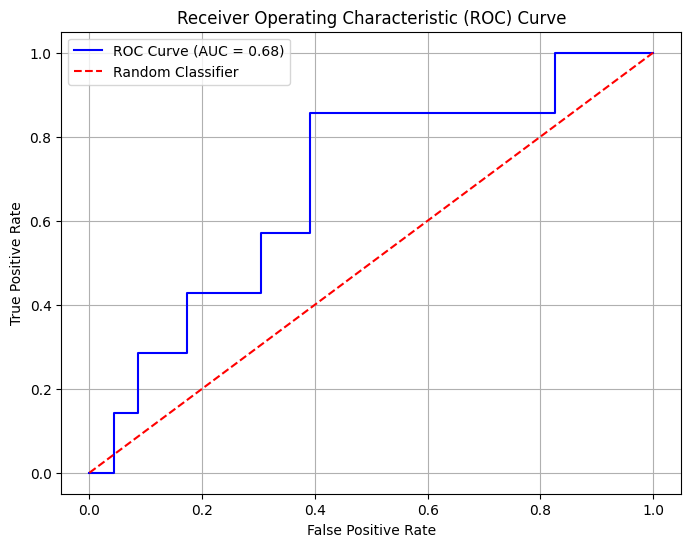

ROC AUC Score: 0.6832


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {auc_score:.4f}")

### Task 10: Test the model with new student records and predict their placement status

In [ ]:
np.random.seed(99)

new_students_data = {
    'CGPA': np.random.uniform(5.0, 9.5, 5),
    'IQ Score': np.random.randint(80, 150, 5),
    'Aptitude Score': np.random.randint(40, 100, 5),
    'Technical Skill Score': np.random.randint(30, 95, 5),
    'Communication Skill Score': np.random.randint(30, 100, 5)
}

new_students_df = pd.DataFrame(new_students_data)

print("New Student Records:")
display(new_students_df)

new_predictions = model.predict(new_students_df)

new_students_df['Predicted Placement'] = new_predictions

print("\nNew Student Records with Predicted Placement Status:")
display(new_students_df)

New Student Records:


,CGPA,IQ Score,Aptitude Score,Technical Skill Score,Communication Skill Score
0,8.025254,81,88,32,89
1,7.196353,103,69,94,69
2,8.714728,115,99,42,77
3,5.141509,135,78,70,57
4,8.636225,145,83,50,92



New Student Records with Predicted Placement Status:


,CGPA,IQ Score,Aptitude Score,Technical Skill Score,Communication Skill Score,Predicted Placement
0,8.025254,81,88,32,89,0
1,7.196353,103,69,94,69,0
2,8.714728,115,99,42,77,1
3,5.141509,135,78,70,57,1
4,8.636225,145,83,50,92,1


## Assignment 2: Polynomial Regression – House Price Prediction

### Task 1: Create a synthetic dataset of at least 30 house records

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

num_records = 30

size_sqft = np.random.randint(1000, 5000, num_records)
num_bedrooms = np.random.randint(2, 6, num_records)
num_bathrooms = np.random.randint(1, 4, num_records)
age_years = np.random.randint(1, 60, num_records)
location_score = np.random.uniform(1.0, 10.0, num_records)

base_price = 150000
size_factor = 100
bed_factor = 20000
bath_factor = 30000
age_factor = 1500
location_factor = 25000
random_noise = np.random.normal(0, 50000, num_records)

price_usd = (base_price +
             size_factor * size_sqft +
             bed_factor * num_bedrooms +
             bath_factor * num_bathrooms -
             age_factor * age_years +
             location_factor * location_score +
             random_noise).round(2)

price_usd[price_usd < 50000] = 50000

house_df = pd.DataFrame({
    'Size (sqft)': size_sqft,
    'Number of Bedrooms': num_bedrooms,
    'Number of Bathrooms': num_bathrooms,
    'Age (years)': age_years,
    'Location Score': location_score,
    'Price (USD)': price_usd
})

print(f"Dataset created with {num_records} house records.")

display(house_df.head())
house_df.info()

Dataset created with 30 house records.


,Size (sqft),Number of Bedrooms,Number of Bathrooms,Age (years),Location Score,Price (USD)
0,4174,2,3,18,1.140728,629882.34
1,4507,2,3,26,4.810613,797925.02
2,1860,5,1,44,4.553934,510857.48
3,2294,3,1,34,3.641394,557493.53
4,2130,3,3,10,1.126718,615882.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Size (sqft)          30 non-null     int64  
 1   Number of Bedrooms   30 non-null     int64  
 2   Number of Bathrooms  30 non-null     int64  
 3   Age (years)          30 non-null     int64  
 4   Location Score       30 non-null     float64
 5   Price (USD)          30 non-null     float64
dtypes: float64(2), int64(4)
memory usage: 1.5 KB


### Task 2: Perform basic data preprocessing and separate features (X) and target (y)

In [ ]:
X_house = house_df.drop('Price (USD)', axis=1)
y_house = house_df['Price (USD)']

print("House Features (X_house) shape:", X_house.shape)
print("House Target (y_house) shape:", y_house.shape)

print("\nFirst 5 rows of X_house:")
display(X_house.head())

print("\nFirst 5 rows of y_house:")
display(y_house.head())

House Features (X_house) shape: (30, 5)
House Target (y_house) shape: (30,)

First 5 rows of X_house:


,Size (sqft),Number of Bedrooms,Number of Bathrooms,Age (years),Location Score
0,4174,2,3,18,1.140728
1,4507,2,3,26,4.810613
2,1860,5,1,44,4.553934
3,2294,3,1,34,3.641394
4,2130,3,3,10,1.126718



First 5 rows of y_house:


,Price (USD)
0,629882.34
1,797925.02
2,510857.48
3,557493.53
4,615882.00


### Task 3: Split the dataset into 80% training and 20% testing data

In [ ]:
from sklearn.model_selection import train_test_split

X_house_train, X_house_test, y_house_train, y_house_test = train_test_split(X_house, y_house, test_size=0.2, random_state=42)

print("House Training and Testing Dataset Sizes:")
print(f"X_house_train shape: {X_house_train.shape}")
print(f"X_house_test shape: {X_house_test.shape}")
print(f"y_house_train shape: {y_house_train.shape}")
print(f"y_house_test shape: {y_house_test.shape}")

House Training and Testing Dataset Sizes:
X_house_train shape: (24, 5)
X_house_test shape: (6, 5)
y_house_train shape: (24,)
y_house_test shape: (6,)


### Task 4: Apply Polynomial Features to the data

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_house_train_poly = poly.fit_transform(X_house_train)
X_house_test_poly = poly.transform(X_house_test)

print("Original training features shape:", X_house_train.shape)
print("Polynomial training features shape:", X_house_train_poly.shape)
print("Original test features shape:", X_house_test.shape)
print("Polynomial test features shape:", X_house_test_poly.shape)

print("\nPolynomial Feature Names:")
print(poly.get_feature_names_out(X_house.columns))

Original training features shape: (24, 5)
Polynomial training features shape: (24, 20)
Original test features shape: (6, 5)
Polynomial test features shape: (6, 20)

Polynomial Feature Names:
['Size (sqft)' 'Number of Bedrooms' 'Number of Bathrooms' 'Age (years)'
 'Location Score' 'Size (sqft)^2' 'Size (sqft) Number of Bedrooms'
 'Size (sqft) Number of Bathrooms' 'Size (sqft) Age (years)'
 'Size (sqft) Location Score' 'Number of Bedrooms^2'
 'Number of Bedrooms Number of Bathrooms' 'Number of Bedrooms Age (years)'
 'Number of Bedrooms Location Score' 'Number of Bathrooms^2'
 'Number of Bathrooms Age (years)' 'Number of Bathrooms Location Score'
 'Age (years)^2' 'Age (years) Location Score' 'Location Score^2']


### Task 5: Train a Linear Regression model on the polynomial features

In [ ]:
from sklearn.linear_model import LinearRegression

poly_reg_model = LinearRegression()
poly_reg_model.fit(X_house_train_poly, y_house_train)

print("Polynomial Regression model (Linear Regression trained on polynomial features) trained successfully.")
print(f"Model Intercept: {poly_reg_model.intercept_:.2f}")

print("\nModel Coefficients:")
coefficients_df = pd.DataFrame({
    'Feature': poly.get_feature_names_out(X_house.columns),
    'Coefficient': poly_reg_model.coef_
})
display(coefficients_df.sort_values(by='Coefficient', ascending=False).head(10))

Polynomial Regression model (Linear Regression trained on polynomial features) trained successfully.
Model Intercept: 6222.75

Model Coefficients:


,Feature,Coefficient
2,Number of Bathrooms,382103.073183
1,Number of Bedrooms,275250.020918
13,Number of Bedrooms Location Score,19905.067643
12,Number of Bedrooms Age (years),4809.989815
15,Number of Bathrooms Age (years),1334.762604
19,Location Score^2,771.582004
7,Size (sqft) Number of Bathrooms,31.766365
9,Size (sqft) Location Score,28.503598
6,Size (sqft) Number of Bedrooms,4.652670
8,Size (sqft) Age (years),3.279772


### Task 6: Make predictions on the test set and evaluate the model's performance

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_house_pred = poly_reg_model.predict(X_house_test_poly)

print("House Price Predictions on Test Set:")
display(pd.DataFrame({'Actual Price': y_house_test, 'Predicted Price': y_house_pred.round(2)}).head())

mae = mean_absolute_error(y_house_test, y_house_pred)
mse = mean_squared_error(y_house_test, y_house_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_house_test, y_house_pred)

print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.4f}")

House Price Predictions on Test Set:


,Actual Price,Predicted Price
27,553943.92,563612.65
15,905965.58,579477.17
23,784525.71,962711.79
17,771465.21,899432.70
8,532211.17,248237.68



Mean Absolute Error (MAE): 174975.64
Mean Squared Error (MSE): 41787420149.19
Root Mean Squared Error (RMSE): 204419.72
R-squared (R2): -1.1756


### Task 7: Visualize the model's predictions against actual prices

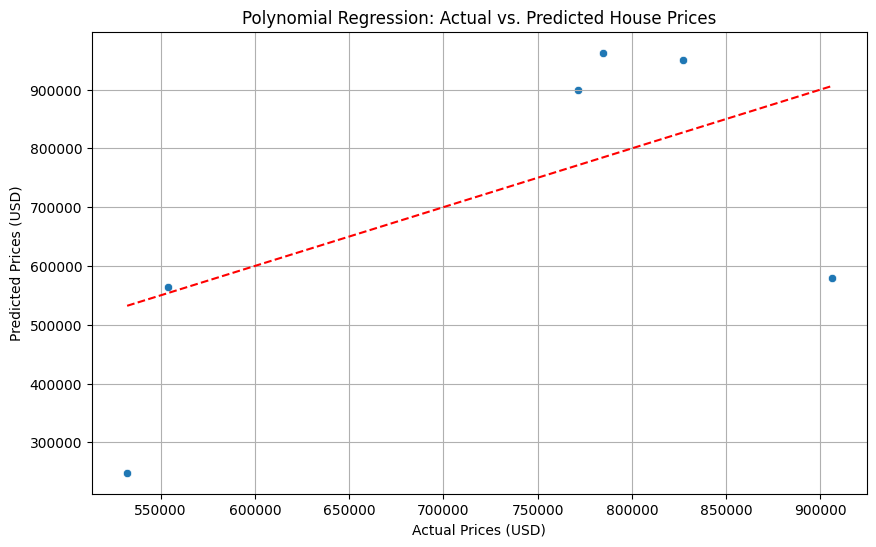

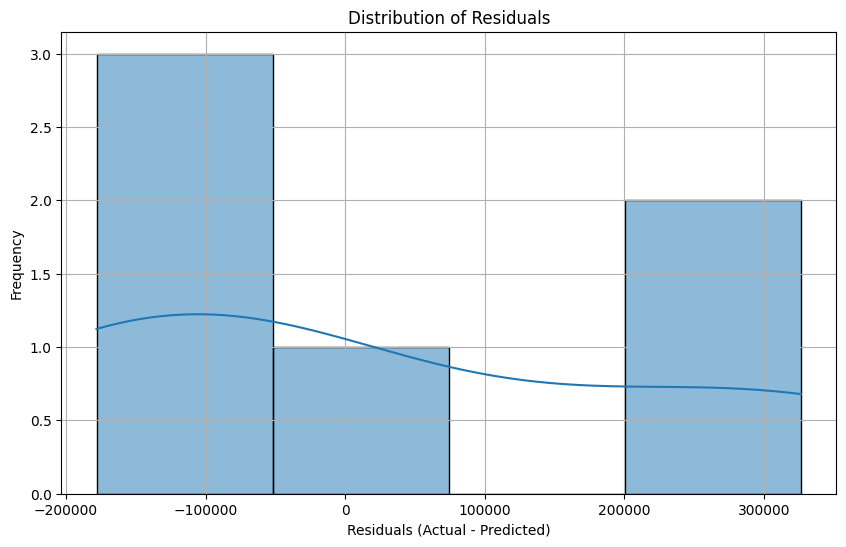

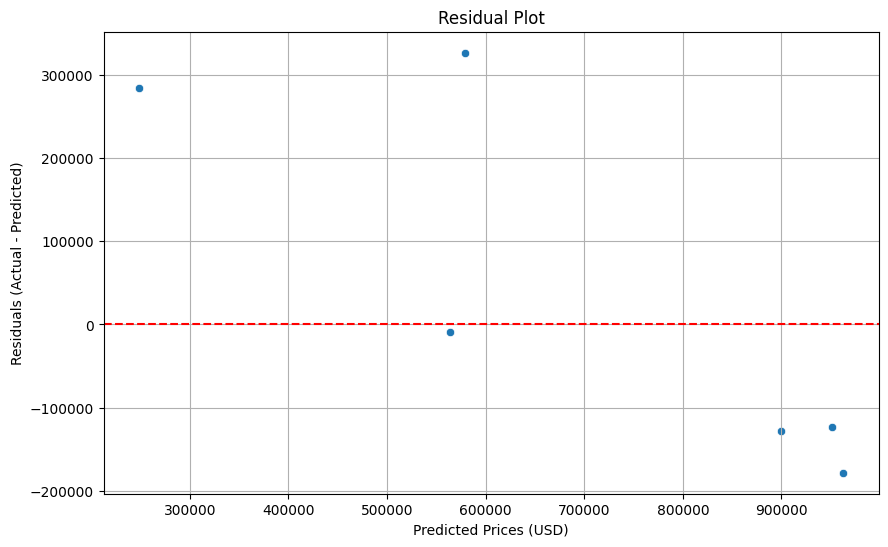

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_house_test, y=y_house_pred)
plt.plot([min(y_house_test), max(y_house_test)], [min(y_house_test), max(y_house_test)], color='red', linestyle='--')
plt.xlabel('Actual Prices (USD)')
plt.ylabel('Predicted Prices (USD)')
plt.title('Polynomial Regression: Actual vs. Predicted House Prices')
plt.grid(True)
plt.show()

residuals = y_house_test - y_house_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_house_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Prices (USD)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

### Task 8: Experiment with different polynomial degrees and compare their performance

Comparing Polynomial Regression models with different degrees:

--- Testing Polynomial Degree 1 ---
  Number of features after transformation: 5
  Mean Absolute Error (MAE): 39035.27
  Root Mean Squared Error (RMSE): 46073.22
  R-squared (R2): 0.8895


--- Testing Polynomial Degree 2 ---
  Number of features after transformation: 20
  Mean Absolute Error (MAE): 174975.64
  Root Mean Squared Error (RMSE): 204419.72
  R-squared (R2): -1.1756


--- Testing Polynomial Degree 3 ---
  Number of features after transformation: 55
  Mean Absolute Error (MAE): 240878.82
  Root Mean Squared Error (RMSE): 265894.99
  R-squared (R2): -2.6809


--- Testing Polynomial Degree 4 ---
  Number of features after transformation: 125
  Mean Absolute Error (MAE): 240229.17
  Root Mean Squared Error (RMSE): 303091.39
  R-squared (R2): -3.7828




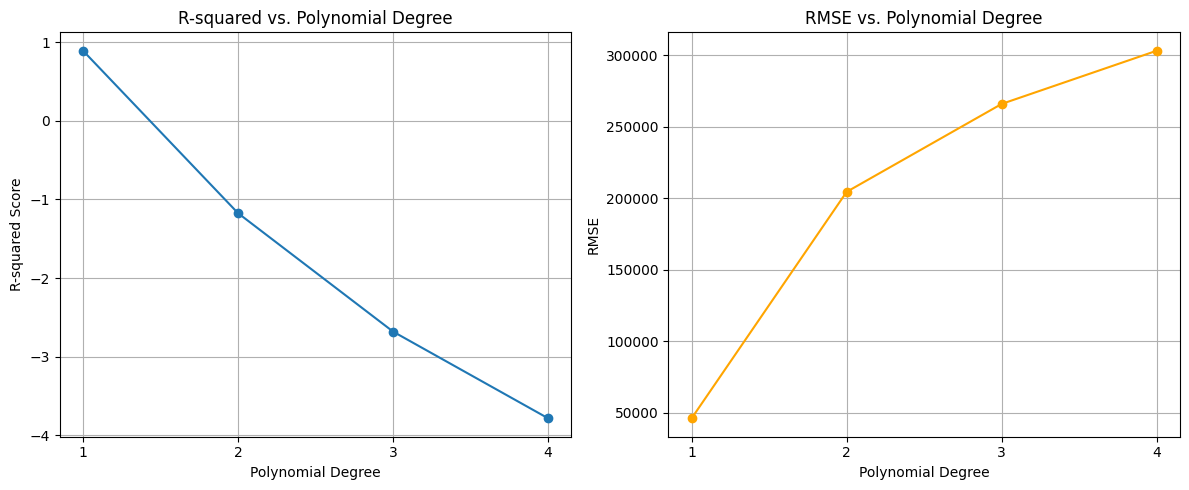

Best polynomial degree based on R-squared: 1 (R2 = 0.8895)
Best polynomial degree based on RMSE: 1 (RMSE = 46073.22)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

degrees_to_test = [1, 2, 3, 4]

r2_scores = []
rmse_scores = []

print("Comparing Polynomial Regression models with different degrees:\n")

for degree in degrees_to_test:
    print(f"--- Testing Polynomial Degree {degree} ---")
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_house_train_poly = poly.fit_transform(X_house_train)
    X_house_test_poly = poly.transform(X_house_test)

    poly_reg_model = LinearRegression()
    poly_reg_model.fit(X_house_train_poly, y_house_train)

    y_house_pred = poly_reg_model.predict(X_house_test_poly)

    mae = mean_absolute_error(y_house_test, y_house_pred)
    mse = mean_squared_error(y_house_test, y_house_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_house_test, y_house_pred)

    r2_scores.append(r2)
    rmse_scores.append(rmse)

    print(f"  Number of features after transformation: {X_house_train_poly.shape[1]}")
    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"  R-squared (R2): {r2:.4f}")
    print("\n")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(degrees_to_test, r2_scores, marker='o')
plt.title('R-squared vs. Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('R-squared Score')
plt.xticks(degrees_to_test)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(degrees_to_test, rmse_scores, marker='o', color='orange')
plt.title('RMSE vs. Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.xticks(degrees_to_test)
plt.grid(True)

plt.tight_layout()
plt.show()

best_degree_r2 = degrees_to_test[np.argmax(r2_scores)]
best_degree_rmse = degrees_to_test[np.argmin(rmse_scores)]

print(f"Best polynomial degree based on R-squared: {best_degree_r2} (R2 = {max(r2_scores):.4f})")
print(f"Best polynomial degree based on RMSE: {best_degree_rmse} (RMSE = {min(rmse_scores):.2f})")

### Task 9: Predict the price of a house having an area of 2000 sq.ft. using the best model

In [ ]:
best_degree = best_degree_r2

print(f"Retraining model with the best polynomial degree: {best_degree}")

poly_best = PolynomialFeatures(degree=best_degree, include_bias=False)
X_house_train_poly_best = poly_best.fit_transform(X_house_train)
X_house_test_poly_best = poly_best.transform(X_house_test)

poly_reg_model_best = LinearRegression()
poly_reg_model_best.fit(X_house_train_poly_best, y_house_train)

new_house_features = pd.DataFrame([[2000, 3, 2, 10, 7.5]],
                                  columns=X_house.columns)

print("\nNew house features:")
display(new_house_features)

new_house_features_poly = poly_best.transform(new_house_features)

predicted_price = poly_reg_model_best.predict(new_house_features_poly)

print(f"\nPredicted price for the new house: ${predicted_price[0]:,.2f}")

Retraining model with the best polynomial degree: 1

New house features:


,Size (sqft),Number of Bedrooms,Number of Bathrooms,Age (years),Location Score
0,2000,3,2,10,7.5



Predicted price for the new house: $646,986.24


### Task 10: Visualize original data vs. linear regression line

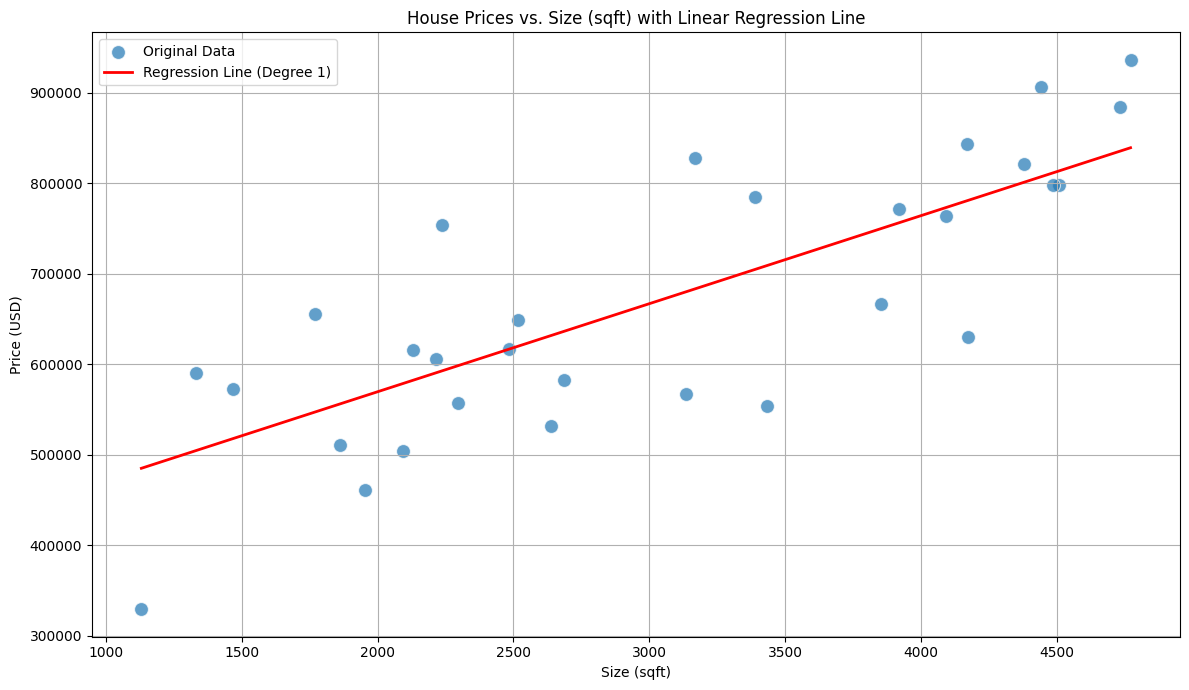

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

size_range = np.linspace(X_house['Size (sqft)'].min(), X_house['Size (sqft)'].max(), 100).reshape(-1, 1)

predict_df = pd.DataFrame({
    'Size (sqft)': size_range.flatten(),
    'Number of Bedrooms': X_house['Number of Bedrooms'].mean(),
    'Number of Bathrooms': X_house['Number of Bathrooms'].mean(),
    'Age (years)': X_house['Age (years)'].mean(),
    'Location Score': X_house['Location Score'].mean()
})

predict_df_poly = poly_best.transform(predict_df)

predicted_prices_line = poly_reg_model_best.predict(predict_df_poly)

plt.figure(figsize=(12, 7))
sns.scatterplot(x=house_df['Size (sqft)'], y=house_df['Price (USD)'], label='Original Data', s=100, alpha=0.7)

predict_df_sorted = predict_df.sort_values(by='Size (sqft)')
predicted_prices_line_sorted = poly_reg_model_best.predict(poly_best.transform(predict_df_sorted))
sns.lineplot(x=predict_df_sorted['Size (sqft)'], y=predicted_prices_line_sorted, color='red', label='Regression Line (Degree 1)', linewidth=2)

plt.title('House Prices vs. Size (sqft) with Linear Regression Line')
plt.xlabel('Size (sqft)')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()